In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [28]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

print("Original shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Cleaned shape:", df.shape)

Original shape: (150, 5)
Missing values: 0
Duplicate rows: 1
Cleaned shape: (149, 5)


In [29]:
X = df.drop("species", axis=1)
y = df["species"]

print("Features:", X.columns.tolist())
print("Target: species")

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target: species
X Shape: (149, 4)
y Shape: (149,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 119
Testing Samples: 30


In [31]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [32]:
predictions = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(predictions))

Predictions generated successfully.
Number of predictions: 30


In [33]:
accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print("MODEL EVALUATION RESULTS")
print("-" * 40)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

MODEL EVALUATION RESULTS
----------------------------------------
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1 Score : 93.33 %


In [34]:
print("Classification Report:")
print()

print(
    classification_report(
        y_test,
        predictions
    )
)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



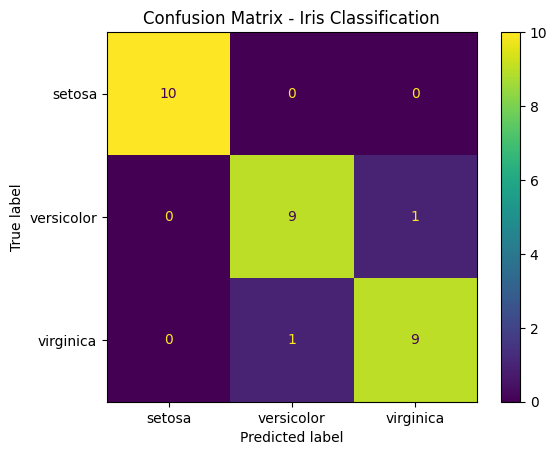

In [39]:
cm = confusion_matrix(
    y_test,
    predictions,
    labels=model.classes_
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

cm_display.plot()

plt.title("Confusion Matrix - Iris Classification")
plt.show()

In [40]:
results = pd.DataFrame({
    "Actual Species": y_test.values,
    "Predicted Species": predictions
})

results["Correct"] = (
    results["Actual Species"] ==
    results["Predicted Species"]
)

results.head(10)

,Actual Species,Predicted Species,Correct
0,versicolor,versicolor,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,setosa,setosa,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,versicolor,versicolor,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


In [41]:
correct = np.sum(y_test.values == predictions)
incorrect = np.sum(y_test.values != predictions)

print("Total Test Samples      :", len(y_test))
print("Correct Predictions     :", correct)
print("Incorrect Predictions   :", incorrect)
print("Accuracy                :", round(accuracy * 100, 2), "%")

Total Test Samples      : 30
Correct Predictions     : 28
Incorrect Predictions   : 2
Accuracy                : 93.33 %


In [42]:
incorrect_results = results[
    results["Correct"] == False
]

if len(incorrect_results) == 0:
    print("No incorrect predictions were found.")
else:
    print("Incorrect Predictions:")
    print(incorrect_results.to_string(index=False))

Incorrect Predictions:
Actual Species Predicted Species  Correct
    versicolor         virginica    False
     virginica        versicolor    False


In [43]:
print("=" * 50)
print("TASK 5: MODEL EVALUATION COMPLETED")
print("=" * 50)

print("Model                 : Random Forest Classifier")
print("Test Samples          :", len(y_test))
print("Accuracy              :", round(accuracy * 100, 2), "%")
print("Precision             :", round(precision * 100, 2), "%")
print("Recall                :", round(recall * 100, 2), "%")
print("F1 Score              :", round(f1 * 100, 2), "%")
print("Correct Predictions   :", correct)
print("Incorrect Predictions :", incorrect)

TASK 5: MODEL EVALUATION COMPLETED
Model                 : Random Forest Classifier
Test Samples          : 30
Accuracy              : 93.33 %
Precision             : 93.33 %
Recall                : 93.33 %
F1 Score              : 93.33 %
Correct Predictions   : 28
Incorrect Predictions : 2


Model Evaluation
The Random Forest classification model was evaluated using the unseen test dataset. Accuracy was used to measure the overall percentage of correctly classified Iris flowers. Precision measured how reliable the model's predictions were for the predicted classes, while recall measured how effectively the model identified the actual flower classes.
The F1-score was also calculated to provide a balanced measure of precision and recall. A confusion matrix was created to show the number of correct and incorrect predictions for Setosa, Versicolor and Virginica.
The evaluation results demonstrate how effectively the trained model generalizes to unseen flower samples. The confusion matrix is particularly useful for identifying whether the model has difficulty distinguishing between specific flower species.
The final performance metrics provide an overall assessment of the Random Forest model and determine whether it is suitable for Iris flower classification.